# Lista 3 - Séries Temporais

### Enunciado:

*Ajustar um modelo para duas séries.*

*Se quiserem tentem ajustar modelo para alguma série de https://finance.yahoo.com/*

*fiquem à vontade.*

# 📈 Análise de Séries Temporais em R

Este notebook apresenta o **procedimento completo** para análise de séries temporais, seguindo a metodologia clássica:

1. Carregamento e visualização dos dados
2. Decomposição da série
3. Teste de estacionariedade
4. Transformações (se necessário)
5. Identificação do modelo (ACF / PACF)
6. Ajuste do modelo ARIMA
7. Diagnóstico dos resíduos
8. Previsão


---

### Série 1

> Usaremos a série clássica `eggs` — preço dos ovos de 1900 a 1993.

In [7]:
library(forecast)
library(tseries)
library(ggplot2)
library(zoo)


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




---
## 1. Carregamento e visualização inicial

O primeiro passo é **olhar pros dados**. Queremos entender:
- Existe **tendência** (crescimento ou queda ao longo do tempo)?
- Existe **sazonalidade** (padrões que se repetem periodicamente)?
- Há **outliers** ou quebras estruturais?
- A variância é **constante** ou cresce com o nível da série?


In [4]:
library(forecast)

# 1. Lê o CSV
dados <- read.csv("eggs.csv")

# 2. Garante que está ordenado por data
dados <- dados[order(dados$ds), ]

# 3. Extrai o ano de início
ano_inicio <- as.integer(format(as.Date(dados$ds[1]), "%Y"))

# 4. Converte para objeto ts (frequência 1 = anual)
ts_data <- ts(dados$y, start = ano_inicio, frequency = 1)

# Informações básicas
cat("Classe:", class(ts_data), "\n")
cat("Início:", start(ts_data), "\n")
cat("Fim:", end(ts_data), "\n")
cat("Frequência:", frequency(ts_data), "observações/ano\n")
cat("Comprimento:", length(ts_data), "observações\n")
cat("\nResumo estatístico:\n")
print(summary(ts_data))

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



Classe: ts 
Início: 1900 1 
Fim: 1993 1 
Frequência: 1 observações/ano
Comprimento: 94 observações

Resumo estatístico:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  62.27  148.87  209.15  206.15  276.71  358.78 


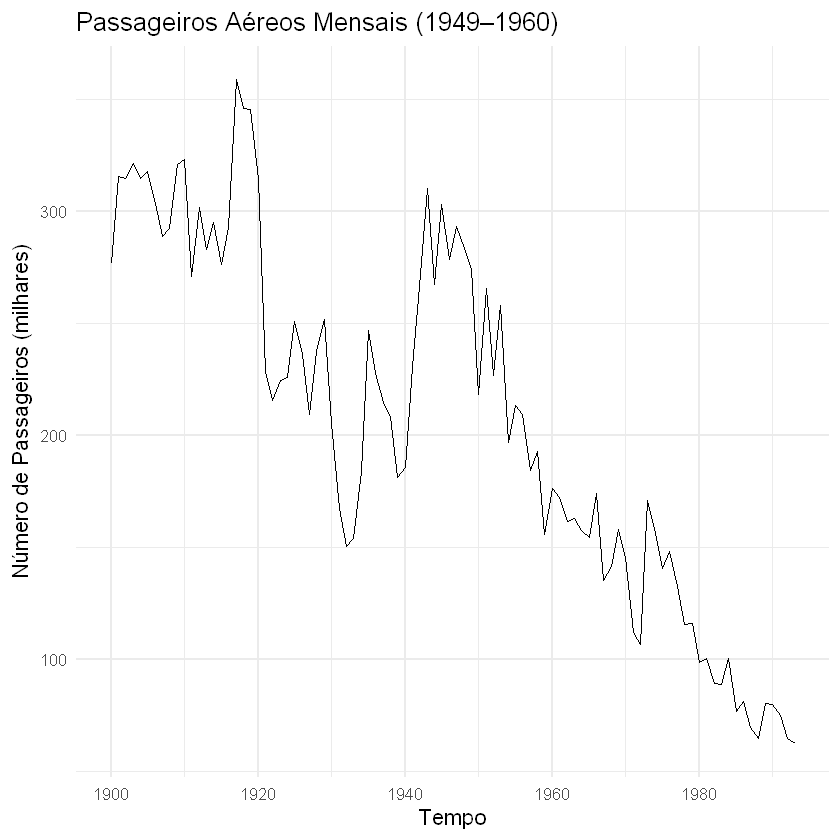

In [ ]:
# Visualização da série original
autoplot(ts_data) +
  labs(
    title = "Preço dos ovos no século XX",
    x = "Ano",
    y = "Preço dos ovos)"
  ) +
  theme_minimal(base_size = 13)

**Observações da visualização:**

- Há uma **tendência decrescente** clara ao longo do tempo.
- Possui **anormalidades**: 2 picos de crescimento bruscos por volta de 1915 e 1945.
- Tirando os picos, a série aparenta ter **Homocedasticidade**.

---
## 2. Decomposição da série

In [ ]:
# Decomposição multiplicativa clássica
decomp <- decompose(ts_data)
autoplot(decomp) +
  labs(title = "Decomposição") +
  theme_minimal(base_size = 12)

ERROR: Error in decompose(ts_data): série temporal não tem período, ou tem menos de 2
